In [1]:
# Importación de librerías 

import pandas as pd
import numpy as np 
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import scipy.stats as st
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
# Carga de dataset y muestra de 10 sujetos

path = "../data/raw/proyecto_g_ensayos_clinicos.csv"

df = pd.read_csv(path)
df.sample(5)

,id_sujeto,edad,tipo_sangre,exposicion_previa_t_virus,nivel_biomarcador_g,carga_viral_inicial,mutacion_estable
4315,SUBJ-01604,42,B+,0,20.805187,568.299052,0
2527,SUBJ-01124,42,AB-,0,9.145307,825.384007,0
325,SUBJ-01212,18,A+,0,10.657708,658.263560,0
2865,SUBJ-01866,24,O+,0,26.335316,434.340159,0
1415,SUBJ-01740,31,B+,1,48.866335,629.380727,0


In [3]:
# Duplicados y datos nulos 

print(f"Número de registros originales del datafram: {len(df)}")
print(f"Datos duplicados:{df.duplicated().sum()}")
print(f"\nDatos nulos: {df.isnull().sum()}")

Número de registros originales del datafram: 5120
Datos duplicados:120

Datos nulos: id_sujeto                      0
edad                           0
tipo_sangre                    0
exposicion_previa_t_virus      0
nivel_biomarcador_g          362
carga_viral_inicial          206
mutacion_estable               0
dtype: int64


In [4]:
# Eliminación de datos duplicados 
df = df.copy().drop_duplicates()

In [5]:
# Redondeo a 3 cifras de variables numéricas contínuas 
df['nivel_biomarcador_g'] = np.round(df['nivel_biomarcador_g'], 3)
df['carga_viral_inicial'] = np.round(df['carga_viral_inicial'],3)

<Figure size 1500x600 with 0 Axes>

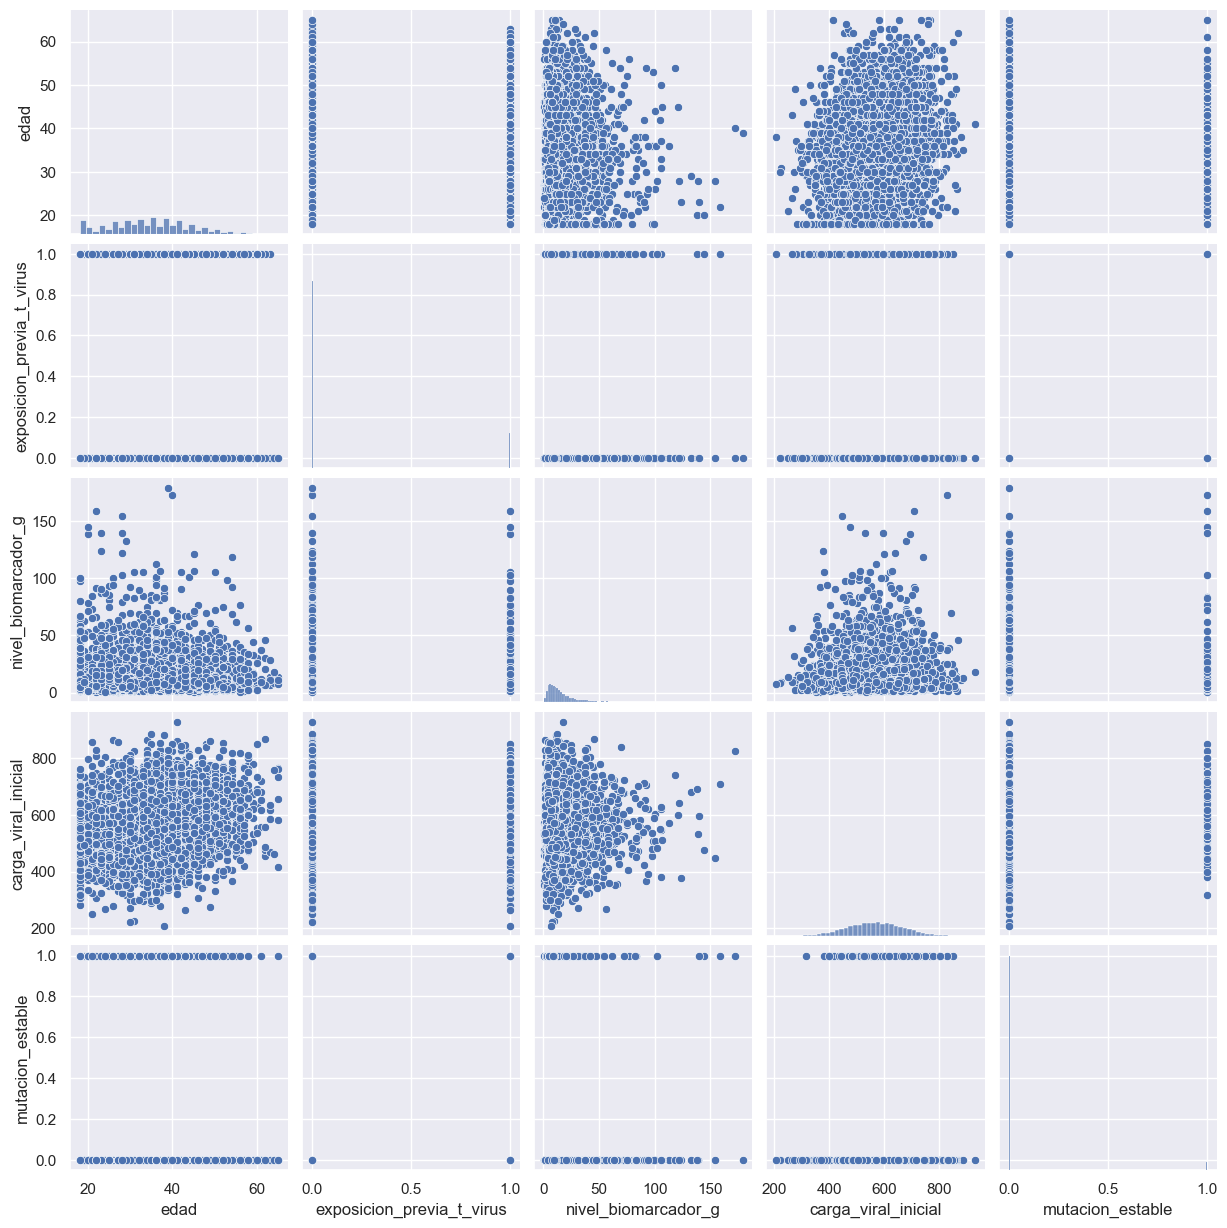

In [6]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(15,6))
sns.pairplot(
    data = df
)
plt.show()

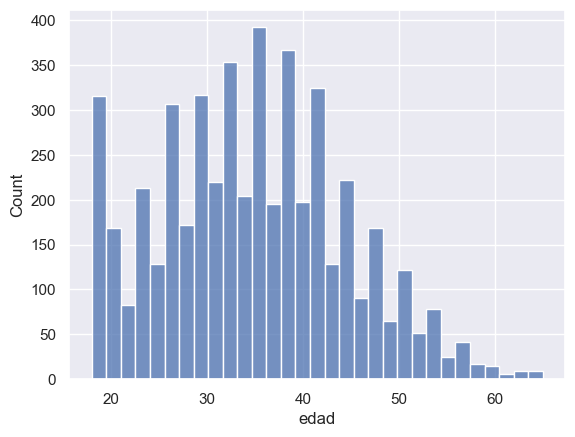

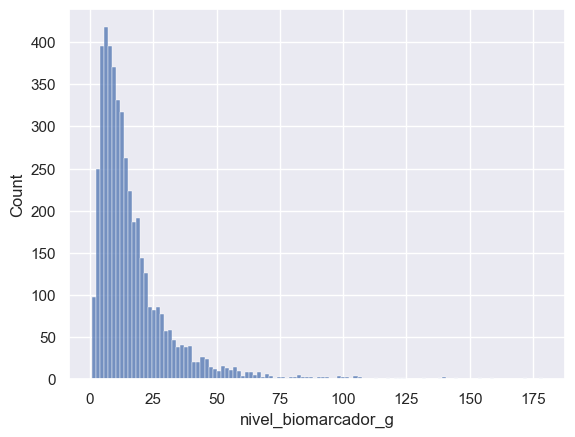

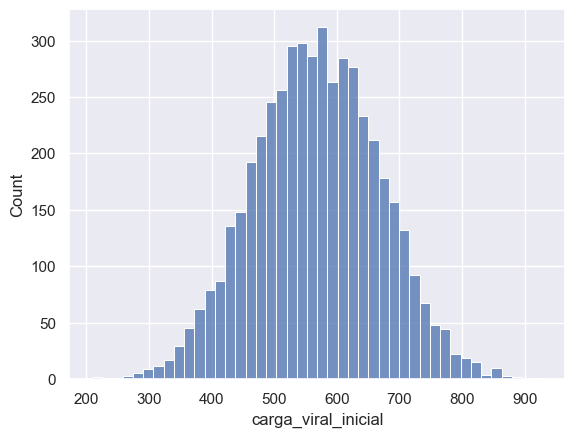

In [7]:
def generacion_histogramas():
    list = ['edad','nivel_biomarcador_g','carga_viral_inicial']
    for l in list:
        sns.histplot(
            data = df, 
            x = l
        )
        plt.show()

generacion_histogramas()

In [8]:
stable = df[df['mutacion_estable'] == 1].count()
non_stable = df[df['mutacion_estable'] != 1].count()
total_registros = df.shape[0]

stable_ = np.round(stable/total_registros * 100,3)
non_stable_ = np.round(non_stable/total_registros * 100,3)

print(f"Stable: {stable_}%")
print(f"\nNon stable:{non_stable_}")

Stable: id_sujeto                    3.48
edad                         3.48
tipo_sangre                  3.48
exposicion_previa_t_virus    3.48
nivel_biomarcador_g          3.28
carga_viral_inicial          3.40
mutacion_estable             3.48
dtype: float64%

Non stable:id_sujeto                    96.52
edad                         96.52
tipo_sangre                  96.52
exposicion_previa_t_virus    96.52
nivel_biomarcador_g          89.72
carga_viral_inicial          92.60
mutacion_estable             96.52
dtype: float64


In [9]:
# Abordar los datos nulos de  las columnas con knnimputer

scaler = StandardScaler()
imputer = KNNImputer(n_neighbors=5, weights='distance')

df['log_biomarcador_g'] = np.log1p(df['nivel_biomarcador_g'])

num_col = num_col = ['log_biomarcador_g', 'carga_viral_inicial']
df_num = df[num_col].copy()

df_scaled = scaler.fit_transform(df_num)
df_num_imputed_scaled = imputer.fit_transform(df_scaled)
df_num_imputed = scaler.inverse_transform(df_num_imputed_scaled)

df[num_col] = df_num_imputed

df.sample(5)


,id_sujeto,edad,tipo_sangre,exposicion_previa_t_virus,nivel_biomarcador_g,carga_viral_inicial,mutacion_estable,log_biomarcador_g
2787,SUBJ-01079,24,B+,1,12.138,558.485,0,2.575509
1453,SUBJ-02164,36,B-,0,5.482,469.215,0,1.869029
1669,SUBJ-03973,18,O-,0,4.616,650.128,0,1.725620
3481,SUBJ-01013,36,O+,0,20.726,521.665,0,3.078510
4508,SUBJ-02000,18,A-,0,NaN,530.064,0,1.522658


In [ ]:
# Revisión de asociación entre dos variables categóricas



t_contingencia = pd.crosstab(
    index = df['exposicion_previa_t_virus'], 
    columns = df['mutacion_estable']
    )

chi2, p_value, dof, freq_esperada = st.chi2_contingency(t_contingencia)

if p_value < 0.5:
    print("Hay una relación estadística significativa entre ambas variables")
    n = t_contingencia.sum().sum() # total de los sujetos de prueba
    grados_libertad = min(t_contingencia.shape) -1
    cramer_v = np.sqrt(chi2/(n*grados_libertad))
    print(f"V de Cramer (Fuerza de asociación): {cramer_v:.4f}")
else:
    print("No hay asociación estadísticamente significativa entre las variables.")


Hay una relación estadística significativa entre ambas variables
V de Cramer (Fuerza de asociación): 0.2885


In [11]:
t_contingencia

mutacion_estable,0,1
exposicion_previa_t_virus,,
0,4165,50
1,661,124


In [14]:
df.head()

,id_sujeto,edad,tipo_sangre,exposicion_previa_t_virus,nivel_biomarcador_g,carga_viral_inicial,mutacion_estable,log_biomarcador_g
0,SUBJ-00530,51,B-,0,13.347,579.183,0,2.663541
1,SUBJ-01729,51,A+,0,29.653,535.838,0,3.422731
2,SUBJ-01010,41,A+,0,NaN,474.473,0,1.980170
3,SUBJ-01149,40,B-,0,24.728,528.745,0,3.247580
4,SUBJ-01383,45,AB-,0,19.140,551.560,0,3.002708


In [ ]:
# Correlación de todas las características contra el objetivo:

def cat_chi2():
    X = df.drop(columns = 'id_sujeto', axis = 1)

        # Variables categóricas 
    cat_cols = X.select_dtypes(include= ['str','category'])
    cat_ctable = pd.crosstab(index = df[cat_cols], columns='mutacion_estable')

    chi2, p_value, dof, _ = st.chi2_contingency(cat_ctable)
    




# Notas

* Se tienen 5120 registros, 120 registros duplicados y valores nulos en las columnas nivel de biomarcador (362) y carga viral inicial (206)
* La carga viral inicial, tiene una distribución normal; el nivel de biomarcador g tiene una distribución de ley de potencias y la edad tiene un distribución que asemeja a lo normal. 
* Se tiene un 3.438% de mutaciones estables y un 96.562% de mutaciones no estables. 
* Existe una relación estadística significativa entre las variables exposición previa al virus y mutación estable

# Reporte de inteligencia de datos: ansayos clínicos del virus G
1. Auditoría y saneamiento de datos (data quality)
Partimos de un lote de 5120 registros clínicos. Se detectaron y purgaron 120 registros duplicados (errores de captura en el sistema central). Además, aplicamos una estrategia de imputación multivariada (KNN Imputer) para rescatar la telemetría fallida en 362 lecturas del biomarcador G y 206 de la carga viral inicial. El dataset resultante ahora es 100% íntegro y denso, listo para modelado sin pérdida de varianza biológica.

2. Análisis de distribuciones y transformaciones

Carga viral inicial: Presenta una distribución normal, lo que indica un muestreo poblacional estable en la fase de infección.

Edad: Distribución cuasi-normal con picos generacionales, representativa de los sujetos de prueba.

Nivel de biomarcador G: Exhibió una distribución de ley de potencias extrema. Se aplicó exitosamente una transformación logarítmica (log_biomarcador_g) para comprimir la asimetría, garantizando que los futuros modelos matemáticos no se sesguen por valores atípicos masivos.

3. Diagnóstico de la variable objetivo
El ensayo clínico tiene una tasa de letalidad/inestabilidad masiva. Apenas el 3.48% de los sujetos logran una mutación estable (clase 1), frente a un 96.52% de fallos celulares catastróficos (clase 0). Este desbalance extremo dicta que la métrica de Accuracy queda descartada para la evaluación del modelo; nuestra optimización deberá centrarse en la Sensibilidad (Recall) y el Área Bajo la Curva Precision-Recall (PR-AUC).

4. Descubrimiento estratégico 
A través de una prueba Chi-cuadrada y el cálculo de la V de Cramer (0.2885), confirmamos estadísticamente la hipótesis central del laboratorio: existe una relación significativa entre la exposición previa al Virus T y la supervivencia a la mutación del Virus G. De hecho, al observar la tabla de contingencia, es revelador que de los 174 casos de éxito totales, 124 ocurrieron en sujetos con exposición previa. Esta variable será el predictor más fuerte de nuestra arquitectura.

In [12]:
# Revisión de dato nulos y datos duplicados 

path = "../data/raw/proyecto_g_ensayos_clinicos.csv"

def null_duplicate(path: str = path):
    df = pd.read_csv(path)
    df = df.drop_duplicates()
    